In [1]:
import pandas as pd
import numpy as np
root="/home/jacoponudo/Documents/Virality-on-Shorts/" # TO CHANGE according to your local path

# Carichiamo i dataset puliti
instagram = pd.read_csv(root + "data/clean/instagram.csv")
tiktok = pd.read_csv(root + "data/clean/tiktok.csv")
youtube = pd.read_csv(root + "data/clean/youtube.csv")

# Filtriamo i publisher attivi per ogni piattaforma
from tools import filter_active_publisher_years
youtube_active, yt_publishers, yt_counts = filter_active_publisher_years(
    df=youtube,
    platform_name="YouTube",
    publisher_col="publisher",
    date_col="published_at",
    min_videos_per_year=70
)

instagram_active, ig_publishers, ig_counts = filter_active_publisher_years(
    df=instagram,
    platform_name="Instagram",
    publisher_col="publisher",
    date_col="published_at",
    min_videos_per_year=70
)

tiktok_active, tt_publishers, tt_counts = filter_active_publisher_years(
    df=tiktok,
    platform_name="TikTok",
    publisher_col="publisher",
    date_col="published_at",
    min_videos_per_year=70
)


# Selezioniamo le colonne di interesse
tiktok=tiktok_active[['video_id','publisher', 'year','views','platform']]
youtube=youtube_active[['video_id','publisher', 'year','views','platform']]
instagram=instagram_active[['video_id','publisher', 'year','views','platform']]

tiktok['views'] =np.log(tiktok['views'].astype(int) + 1)
youtube['views'] =np.log(youtube['views'].astype(int) + 1)
instagram['views'] =np.log(instagram['views'].astype(int) + 1)


YouTube
-------
Original videos:              51,863
Original publishers:          130
Videos after filtering:       47,185
Unique publishers retained:   53

Publisher-years retained by year:
year
2022     8
2023    17
2024    24
2025    42
2026    39
Name: count, dtype: int64

Instagram
---------
Original videos:              235,743
Original publishers:          161
Videos after filtering:       227,976
Unique publishers retained:   130

Publisher-years retained by year:
year
2022     30
2023     97
2024    103
2025    121
2026    103
Name: count, dtype: int64

TikTok
------
Original videos:              195,672
Original publishers:          160
Videos after filtering:       189,948
Unique publishers retained:   119

Publisher-years retained by year:
year
2022    28
2023    60
2024    76
2025    94
2026    86
Name: count, dtype: int64


Preview of channel-year summary table:
    platform  publisher  year  n_videos_original  gini_mean  gini_ci_low  \
0  Instagram      AMICA  2023                101   0.445654     0.364967   
1  Instagram      AMICA  2024                189   0.590398     0.412329   
2  Instagram      AMICA  2025                243   0.642160     0.452943   
3  Instagram      AMICA  2026                103   0.664756     0.557175   
4  Instagram  Adnkronos  2023                128   0.631654     0.431686   

   gini_ci_high  
0      0.525960  
1      0.760858  
2      0.735651  
3      0.738719  
4      0.769772  

Total channel-years analyzed: 928

OPTION G - Gini coefficient of views (linear scale)
            Mixed Linear Model Regression Results
Model:               MixedLM   Dependent Variable:   gini_mean
No. Observations:    928       Method:               REML     
No. Groups:          285       Scale:                0.0083   
Min. group size:     1         Log-Likelihood:       667.2598 
Max. g

/home/jacoponudo/Documents/Virality-on-Shorts/.venv/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


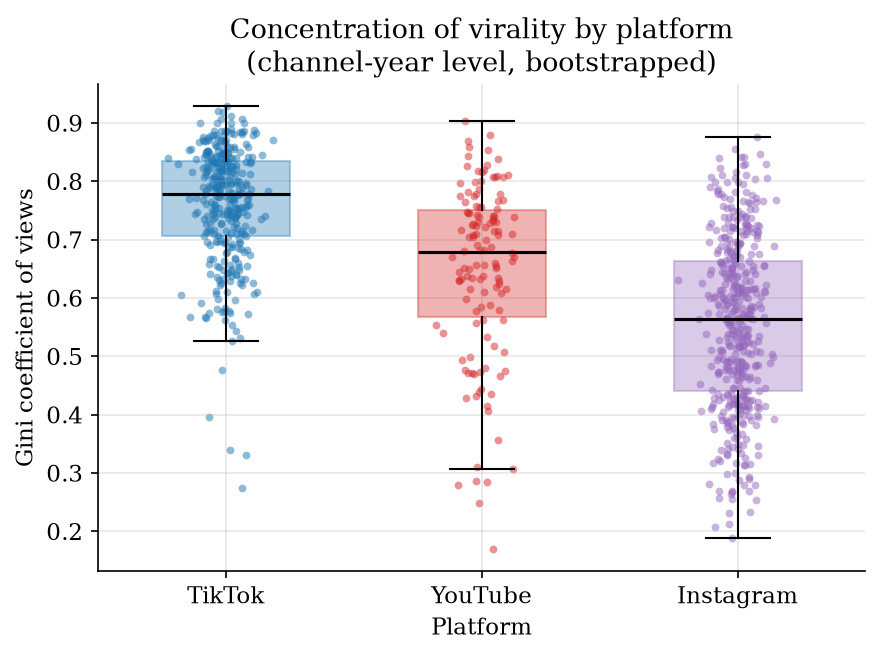

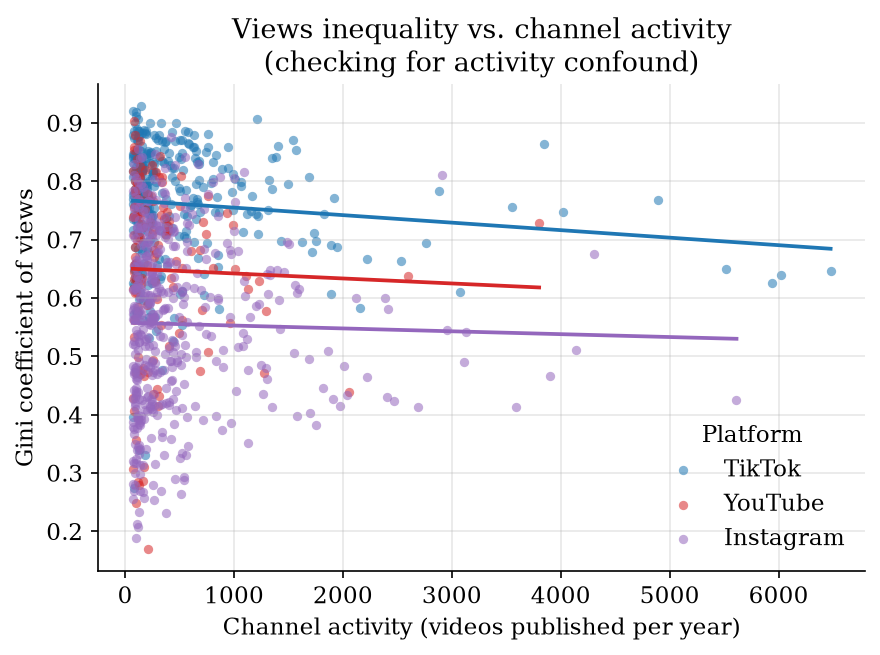

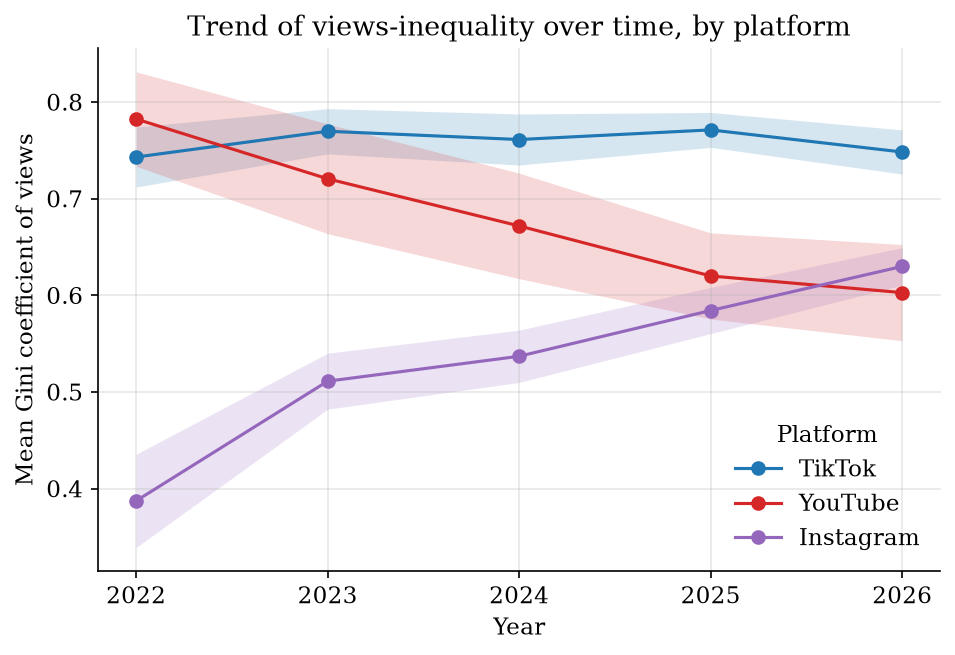


Saved 3 figures (PDF + PNG) to 'figures_gini/'


In [4]:
"""
Option G - Gini Coefficient (inequality/concentration of virality)
==========================================================================

Metric: Gini coefficient of the views distribution, computed per
channel-year.

Rationale: while b-value and quantile-ratio capture the "heaviness"
of the upper tail, and entropy captures how spread out the
distribution is across bins, the Gini coefficient captures how
UNEQUALLY views are distributed across a channel's videos. A channel
where every video gets roughly the same number of views has a LOW
Gini (equal/egalitarian distribution of attention). A channel where
a handful of videos hoover up almost all the views while most videos
flop has a HIGH Gini (unequal/concentrated distribution of
attention).

IMPORTANT METHODOLOGICAL NOTE
------------------------------
The Gini coefficient is a measure of relative inequality defined on
non-negative values in their natural (linear) scale: it is NOT
invariant to a log transform, and computing it on log(views+1)
would understate inequality and change its interpretation (a Gini
on log-views answers "how unequal are the *orders of magnitude* of
views", not "how unequal are the views themselves"). Since the
upstream pipeline stores 'views' already as np.log(views + 1) (to
match the input format used for Option F / entropy), this script
back-transforms to the original views scale via
    views_raw = exp(log_views) - 1
before computing the Gini coefficient. This mirrors what a reviewer
would expect: b-value/entropy are computed in log-space (fine,
common for heavy-tailed magnitudes), but Gini is computed in
linear space (required for the standard definition/interpretation
of the coefficient).

Estimator
---------
For a sorted (ascending) sample x_1 <= x_2 <= ... <= x_n of views:
    G = (2 * sum(i * x_i for i=1..n)) / (n * sum(x_i)) - (n + 1) / n
G in [0, 1]:
    G = 0  -> perfect equality (all videos get the same views)
    G = 1  -> maximum inequality (all views concentrated in one video)

Bootstrap rationale
--------------------
Like entropy, Gini estimates from small samples are noisy and biased
by activity level (few videos = unstable estimate; more videos =
mechanically more room for inequality to show up). We resample with
replacement to a fixed N=100 per channel-year, repeated B=100 times,
and average, so channels with different activity levels are compared
at equal exposure.

Expected input
--------------
tiktok, youtube, instagram: DataFrames with columns
  ['video_id', 'publisher', 'year', 'views', 'platform']
where 'views' is already np.log(views + 1) (consistent with the
other Option scripts). This script exponentiates back internally.

Plots (for paper)
-----------------
Fig. 1: Boxplot of gini_mean by platform -> distribution comparison
Fig. 2: gini_mean vs n_videos_original by platform -> confound check
Fig. 3: gini_mean trend over year by platform (mean +/- 95% CI)
"""

import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf

np.random.seed(42)

N_BOOT = 100
B_REPLICATES = 100

FIGURE_DIR = "figures_gini"

# ----------------------------------------------------------------------
# Publication-style matplotlib settings
# ----------------------------------------------------------------------
PLATFORM_COLORS = {
    "TikTok": "#1f77b4",
    "YouTube": "#d62728",
    "Instagram": "#9467bd",
}

plt.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "font.size": 11,
    "font.family": "serif",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "legend.frameon": False,
})


def gini_coefficient(x):
    """Gini coefficient of x (non-negative values, linear scale).

    x: array of raw (non-log) views.
    Returns NaN if fewer than 2 non-negative, non-degenerate values.
    """
    x = np.asarray(x, dtype=float)
    x = x[~np.isnan(x)]
    x = np.clip(x, 0, None)  # Gini requires non-negative values

    if len(x) < 2 or np.allclose(x, x[0]):
        return np.nan

    total = x.sum()
    if total <= 0:
        return np.nan

    x_sorted = np.sort(x)
    n = len(x_sorted)
    index = np.arange(1, n + 1)
    G = (2 * np.sum(index * x_sorted)) / (n * total) - (n + 1) / n
    return G


def bootstrap_gini(all_data):
    records = []
    for key, grp in all_data.groupby("group_key"):
        views_raw = grp["views_raw"].values
        platform = grp["platform"].iloc[0]
        publisher = grp["publisher"].iloc[0]
        year = grp["year"].iloc[0]
        n_original = len(views_raw)

        gini_boot = []
        for _ in range(B_REPLICATES):
            sample = np.random.choice(views_raw, size=N_BOOT, replace=True)
            gini_boot.append(gini_coefficient(sample))

        records.append({
            "platform": platform,
            "publisher": publisher,
            "year": year,
            "n_videos_original": n_original,
            "gini_mean": np.nanmean(gini_boot),
            "gini_ci_low": np.nanpercentile(gini_boot, 2.5),
            "gini_ci_high": np.nanpercentile(gini_boot, 97.5),
        })
    return pd.DataFrame(records)


def _platform_order(summary):
    """Consistent platform ordering/colors across all figures."""
    preferred = [p for p in ["TikTok", "YouTube", "Instagram"] if p in summary["platform"].unique()]
    return preferred or sorted(summary["platform"].unique())


def _color_for(platform):
    return PLATFORM_COLORS.get(platform, "#7f7f7f")


def plot_boxplot_by_platform(summary, out_dir):
    """Fig. 1: distribution of gini_mean by platform (boxplot + jittered points)."""
    platforms = _platform_order(summary)
    fig, ax = plt.subplots(figsize=(6, 4.5))

    data = [summary.loc[summary["platform"] == p, "gini_mean"].dropna().values for p in platforms]
    bp = ax.boxplot(
        data,
        widths=0.5,
        patch_artist=True,
        showfliers=False,
        medianprops={"color": "black", "linewidth": 1.5},
    )
    ax.set_xticks(range(1, len(platforms) + 1))
    ax.set_xticklabels(platforms)
    for patch, p in zip(bp["boxes"], platforms):
        patch.set_facecolor(_color_for(p))
        patch.set_alpha(0.35)
        patch.set_edgecolor(_color_for(p))

    rng = np.random.default_rng(0)
    for i, (p, vals) in enumerate(zip(platforms, data), start=1):
        jitter = rng.normal(0, 0.06, size=len(vals))
        ax.scatter(np.full(len(vals), i) + jitter, vals,
                   color=_color_for(p), alpha=0.5, s=14, linewidths=0)

    ax.set_ylabel("Gini coefficient of views")
    ax.set_xlabel("Platform")
    ax.set_title("Concentration of virality by platform\n(channel-year level, bootstrapped)")

    fig.tight_layout()
    plt.show()


def plot_gini_vs_activity(summary, out_dir):
    """Fig. 2: gini_mean vs channel activity (n_videos_original), by platform."""
    platforms = _platform_order(summary)
    fig, ax = plt.subplots(figsize=(6, 4.5))

    for p in platforms:
        sub = summary[summary["platform"] == p].dropna(subset=["gini_mean"])
        ax.scatter(
            sub["n_videos_original"], sub["gini_mean"],
            color=_color_for(p), alpha=0.55, s=20, label=p, linewidths=0,
        )
        if len(sub) > 2:
            coeffs = np.polyfit(sub["n_videos_original"], sub["gini_mean"], 1)
            x_line = np.linspace(sub["n_videos_original"].min(), sub["n_videos_original"].max(), 50)
            ax.plot(x_line, np.polyval(coeffs, x_line), color=_color_for(p), linewidth=1.8)

    ax.set_xlabel("Channel activity (videos published per year)")
    ax.set_ylabel("Gini coefficient of views")
    ax.set_title("Views inequality vs. channel activity\n(checking for activity confound)")
    ax.legend(title="Platform", loc="best")

    fig.tight_layout()
    plt.show()


def plot_gini_trend_by_year(summary, out_dir):
    """Fig. 3: yearly mean gini_mean +/- 95% CI, by platform."""
    platforms = _platform_order(summary)
    fig, ax = plt.subplots(figsize=(6.5, 4.5))

    for p in platforms:
        sub = summary[summary["platform"] == p].dropna(subset=["gini_mean"]).copy()
        sub["year"] = sub["year"].astype(int)
        grouped = sub.groupby("year")["gini_mean"].agg(["mean", "std", "count"]).reset_index()
        grouped["se"] = grouped["std"] / np.sqrt(grouped["count"])
        grouped["ci95"] = 1.96 * grouped["se"]
        grouped = grouped.sort_values("year")

        ax.plot(grouped["year"], grouped["mean"], marker="o", color=_color_for(p), label=p)
        ax.fill_between(
            grouped["year"],
            grouped["mean"] - grouped["ci95"],
            grouped["mean"] + grouped["ci95"],
            color=_color_for(p), alpha=0.18, linewidth=0,
        )

    ax.set_xlabel("Year")
    ax.set_ylabel("Mean Gini coefficient of views")
    ax.set_title("Trend of views-inequality over time, by platform")
    ax.set_xticks(sorted(summary["year"].astype(int).unique()))
    ax.legend(title="Platform", loc="best")

    fig.tight_layout()
    plt.show()


def generate_plots(summary, out_dir=FIGURE_DIR):
    os.makedirs(out_dir, exist_ok=True)
    plot_boxplot_by_platform(summary, out_dir)
    plot_gini_vs_activity(summary, out_dir)
    plot_gini_trend_by_year(summary, out_dir)
    print(f"\nSaved 3 figures (PDF + PNG) to '{out_dir}/'")


def main():

    all_data = pd.concat([tiktok, youtube, instagram], ignore_index=True)
    all_data = all_data.rename(columns={"views": "log_views"})

    # Back-transform to raw views scale: Gini must be computed on the
    # original (linear) scale, not on log(views + 1). See module
    # docstring for why.
    all_data["views_raw"] = np.exp(all_data["log_views"]) - 1

    all_data["group_key"] = (
        all_data["platform"].astype(str) + "_" +
        all_data["publisher"].astype(str) + "_" +
        all_data["year"].astype(str)
    )

    # --- 2. Bootstrap the Gini metric per channel-year ---
    summary = bootstrap_gini(all_data)
    summary["year"] = summary["year"].astype(str)

    print("Preview of channel-year summary table:")
    print(summary.head())
    print(f"\nTotal channel-years analyzed: {len(summary)}")

    # --- 3. Mixed model: gini ~ platform + year + activity, random effect per channel ---
    model_G = smf.mixedlm(
        "gini_mean ~ platform + year + n_videos_original",
        data=summary,
        groups=summary["publisher"],
    ).fit()

    print("\n" + "=" * 70)
    print("OPTION G - Gini coefficient of views (linear scale)")
    print("=" * 70)
    print(model_G.summary())

    summary.to_csv("virality_option_g_summary.csv", index=False)
    print("\nSaved: virality_option_g_summary.csv")

    # --- 4. Plots for the paper ---
    generate_plots(summary)


if __name__ == "__main__":
    main()